# Missing-data PCA (mdPCA)

Missing-data PCA is useful when genotype matrices are too incomplete for ordinary PCA assumptions. Ancient DNA is a common example: every individual can have sparse coverage, and there may be no fully observed reference individuals. This notebook masks 70% of genotypes at random for every individual, then compares ordinary PCA fallbacks with mdPCA.

## Build a structured genotype dataset

The synthetic dataset has 200 individuals and 1,000 SNPs. The population labels are geography-like source groups; all samples, including the reference-like groups, will receive the same random missingness process.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.metrics import silhouette_score

from snputils import mdPCA
from snputils.datasets import build_synthetic_mdpca_dataset
from snputils.visualization import plot_embedding, scatter

RESULTS_DIR = Path("results/tutorials/mdpca")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SEED = 20240520

dataset = build_synthetic_mdpca_dataset(
    n_samples=200,
    n_snps=1_000,
    seed=SEED,
)
snpobj = dataset["snpobj"]
laiobj = dataset["laiobj"]
labels = dataset["labels"]

print(snpobj)
labels["label"].value_counts().rename_axis("label").reset_index(name="n_samples")

SNPObject(shape=(1000, 200, 2), n_snps=1000, n_samples=200, genotypes_shape=(1000, 200, 2), calldata_lai_shape=(1000, 200, 2), calldata_gp_shape=None, has_variant_metadata=True, has_ancestry_map=True)


,label,n_samples
0,AFR_ref,40
1,EUR_ref,40
2,EAS_ref,40
3,ADMIXED_AFR_EUR,40
4,ADMIXED_EUR_EAS,40


## Mask 70% of every individual

This is missing completely at random across SNPs, samples, and haplotypes.

In [2]:
rng = np.random.default_rng(SEED + 1)
missing_rate = 0.70

incomplete = snpobj.copy()
genotypes = snpobj.genotypes.copy()
missing = rng.random(genotypes.shape) < missing_rate
genotypes[missing] = -1
incomplete.genotypes = genotypes

observed_fraction = (genotypes >= 0).mean(axis=(0, 2))
complete_variant_mask = np.all(genotypes >= 0, axis=(1, 2))

print(f"Mean observed genotype fraction per individual: {observed_fraction.mean():.3f}")
print(f"Range across individuals: {observed_fraction.min():.3f} - {observed_fraction.max():.3f}")
print(f"Complete-case SNPs left for ordinary PCA: {complete_variant_mask.sum()} of {snpobj.n_snps}")

Mean observed genotype fraction per individual: 0.298
Range across individuals: 0.271 - 0.327
Complete-case SNPs left for ordinary PCA: 0 of 1000


## Ordinary PCA fallback: zero-filled missing calls

Complete-case PCA has no SNPs left. A common but poor fallback is to fill missing genotypes with a fixed value and run ordinary PCA. Here missing diploid dosages are filled with 0, which strongly weakens the population structure.

Population-label silhouette after zero-filled PCA: 0.003


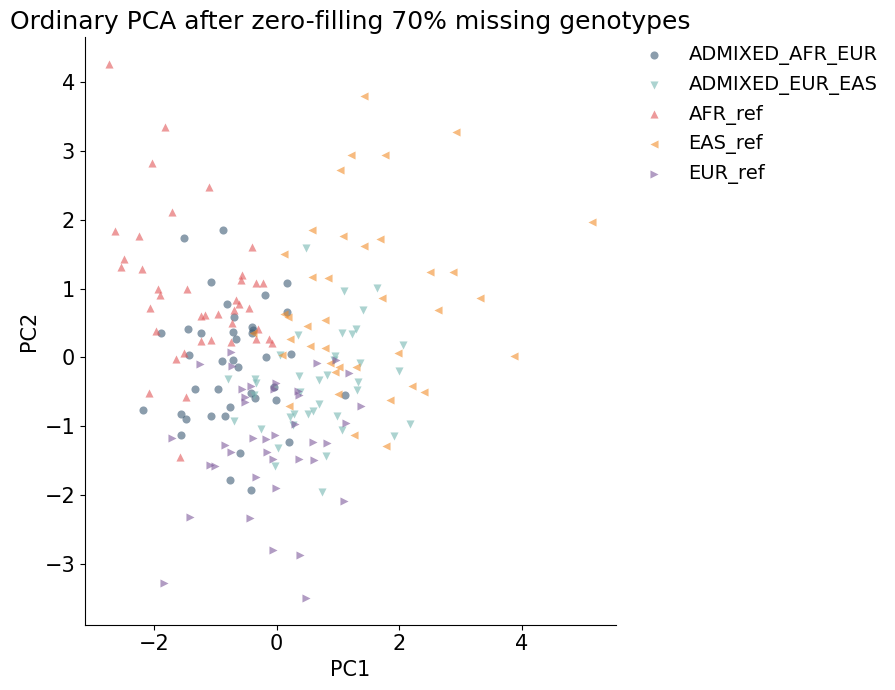

In [3]:
def dosage_matrix(snp):
    gt = snp.genotypes
    dosage = gt.sum(axis=2).astype(float)
    dosage[np.any(gt < 0, axis=2)] = np.nan
    return dosage.T  # samples x SNPs

X_missing = dosage_matrix(incomplete)
X_zero_filled = np.nan_to_num(X_missing, nan=0.0)

ordinary_coords = SklearnPCA(n_components=2, random_state=SEED).fit_transform(X_zero_filled)
ordinary_df = labels.copy()
ordinary_df["PC1"] = ordinary_coords[:, 0]
ordinary_df["PC2"] = ordinary_coords[:, 1]

ordinary_silhouette = silhouette_score(ordinary_coords, ordinary_df["label"])
print(f"Population-label silhouette after zero-filled PCA: {ordinary_silhouette:.3f}")

plot_embedding(ordinary_df, hue="label", title="Ordinary PCA after zero-filling 70% missing genotypes")
plt.show()

## mdPCA on the same incomplete matrix

`mdPCA` computes the covariance structure while respecting missing values. Here `is_masked=False` means the example is about missing genotypes themselves, not ancestry-specific masking. Every individual still has about 70% missing calls.

In [4]:
mdpca = mdPCA(
    snpobj=incomplete,
    laiobj=laiobj,
    labels=labels,
    ancestry=1,
    is_masked=False,
    average_strands=True,
    min_percent_snps=1,
    group_snp_frequencies_only=False,
    n_components=2,
)

mdpca_silhouette = silhouette_score(mdpca.X_new_, labels["label"])
print(f"Population-label silhouette after mdPCA: {mdpca_silhouette:.3f}")
print("mdPCA embedding shape:", mdpca.X_new_.shape)

Population-label silhouette after mdPCA: 0.675
mdPCA embedding shape: (200, 2)


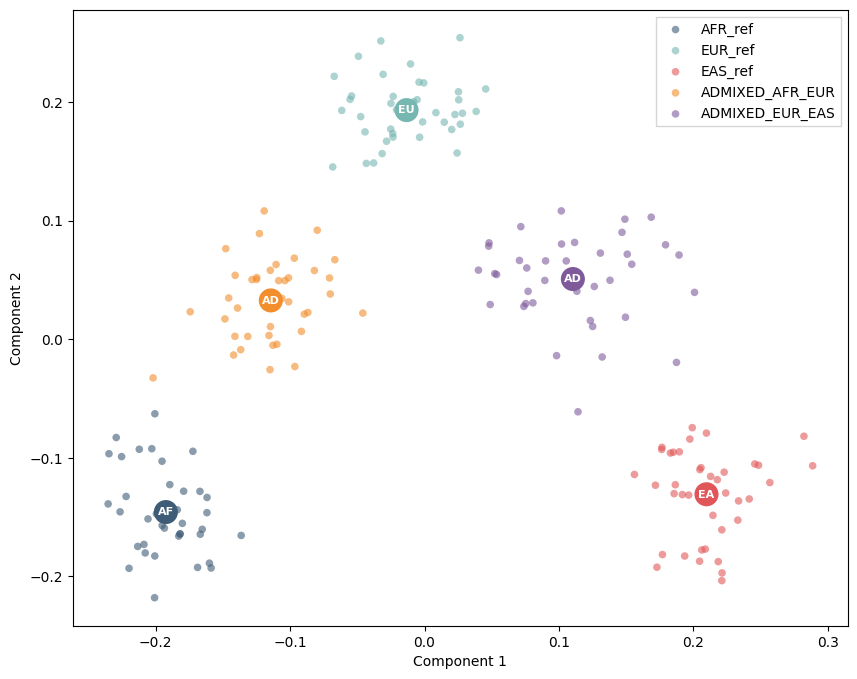

In [5]:
scatter(mdpca, labels)
plt.show()